In [331]:
from openai import OpenAI
from dotenv import load_dotenv
import os
from IPython.display import JSON, display
import json
import math

load_dotenv(dotenv_path='.env', override=True)
client = OpenAI()
[m.id for m in client.models.list()]

['1 - GPT-OSS-120b - an open model released by OpenAI in August 2025',
 '15 Apertus-8B-Instruct-2509 - A new swiss model from September 2025',
 'Tongyi-DeepResearch-30B-A3B',
 'alias-large',
 'alias-fast',
 'Qwen3-VL-32B-Instruct-FP8',
 'alias-apertus',
 '7 - Qwen3-Coder-30B-A3B-Instruct - A code model from August 2025',
 'Phi-4-multimodal-instruct',
 '1 - Ministral 8b - the fast model',
 'Qwen3-Next']

In [332]:
# --- Visualization of OpenAI Responses ---
import math
import numpy as np
from IPython.display import HTML, display
from matplotlib.colors import LinearSegmentedColormap, rgb2hex

# --- color maps (probability: red→white→green, perplexity: white→red) ---
_red = (252/255, 121/255, 125/255, 1.0)
_white = (1.0, 1.0, 1.0, 1.0)
_green = (166/255, 234/255, 173/255, 1.0)

_cm_prob = LinearSegmentedColormap.from_list("prob_cmap", [_red, _white, _green], N=100)
_cm_pplx = LinearSegmentedColormap.from_list("pplx_cmap", [_white, _red], N=100)

def _safe_exp(x: float) -> float:
    """exp(x) with handling for -inf."""
    if x is None:
        return 0.0
    if x == float("-inf"):
        return 0.0
    try:
        return float(math.exp(x))
    except Exception:
        return 0.0

def _norm01(arr):
    """Normalize a 1D array to [0,1] (returns zeros if constant/empty)."""
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        return arr
    lo, hi = float(np.min(arr)), float(np.max(arr))
    if hi <= lo:
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)

def _to_text(token: str) -> str:
    """
    Decode token display the same way as your prior code:
    - 'Ġ' -> space
    - 'Ċ' -> '\n'
    - replace spaces with '░' to visualize spacing
    """
    return token.replace("Ġ", " ").replace("Ċ", "\\n").replace(" ", "░")

def _get_attr_or_item(obj, key, default=None):
    """Try attribute first, then mapping access, else default."""
    if obj is None:
        return default
    if hasattr(obj, key):
        return getattr(obj, key)
    if isinstance(obj, dict):
        return obj.get(key, default)
    return default

def _normalize_top_logprobs(top) -> dict:
    """
    Normalize various SDK shapes of top_logprobs into {token: logprob} dict.
    Accepts:
      - list of objects (with .token and .logprob)
      - list of dicts (with ['token'], ['logprob'])
      - already a dict {token: logprob}
    """
    if top is None:
        return {}
    if isinstance(top, dict):
        return {str(k): float(v) for k, v in top.items()}
    if isinstance(top, (list, tuple)):
        out = {}
        for alt in top:
            tok = _get_attr_or_item(alt, "token", None)
            lp = _get_attr_or_item(alt, "logprob", None)
            if tok is not None and lp is not None:
                out[str(tok)] = float(lp)
        return out
    return {}

def _token_entropy_from_dict(top_dict: dict) -> float:
    """
    Shannon entropy (in nats) given {token: logprob}.
    Assumes values are log-probabilities that exponentiate to probabilities.
    """
    if not top_dict:
        return 0.0
    log_probs = np.array(list(top_dict.values()), dtype=float)
    probs = np.exp(log_probs)
    # guard against numerical issues
    probs = probs / (probs.sum() + 1e-12)
    return float(-np.sum(probs * np.log(probs + 1e-12)))

def _top_logprobs_to_html(top_dict: dict) -> str:
    """Build the hover table HTML with probability bar visualization."""
    if not top_dict:
        return '<table class="top-logprobs"><tr><td colspan="2">no alternatives</td></tr></table>'

    # Sort by probability (descending)
    items = sorted(top_dict.items(), key=lambda kv: _safe_exp(kv[1]), reverse=True)

    rows = []
    for tok, lp in items:
        prob = _safe_exp(float(lp))
        formatted = f"{prob:.3f}" if prob >= 0.001 else "<0.001"
        prob_pct = prob * 100  # convert to percent for CSS

        # Background gradient: blue (alpha=0.6) for first `prob_pct`, transparent rest
        bg_style = (
            f"background: linear-gradient(to right, "
            f"rgba(0, 120, 255, 0.6) {prob_pct:.1f}%, "
            f"rgba(0, 120, 255, 0.05) {prob_pct:.1f}%);"
        )

        rows.append(
            "<tr>"
            f"<td>{_to_text(str(tok))}</td>"
            f"<td style='{bg_style} text-align:right; padding:0 0.5em;'>{formatted}</td>"
            "</tr>"
        )

    return '<table class="top-logprobs" style="line-height: 1.4em;">' + "".join(rows) + "</table>"

def get_html_visualization(response, highlight: str = "probability"):
    """
    Build and display an HTML visualization of tokens with hoverable alternatives.
    - response: OpenAI API response object with logprobs (attribute-style access).
      Expected shape (OpenAI Chat API with logprobs=True):
        response.choices[0].logprobs.content -> list of entries
        each entry has: .token (str), .logprob (float), .top_logprobs (list/dict)
    - highlight: 'probability' or 'perplexity'
    Returns:
      tokens_list, html_string
      where tokens_list = [[decoded_token_str, probability], ...]
    """
    # Extract the first choice
    choices = _get_attr_or_item(response, "choices", None)
    if not choices:
        html = "<i>No choices in response.</i>"
        display(HTML(html))
        return [], html

    choice0 = choices[0]
    logprobs = _get_attr_or_item(choice0, "logprobs", None)
    content = _get_attr_or_item(logprobs, "content", None)
    if not content:
        html = "<i>No token-level logprobs found (did you set logprobs=True?).</i>"
        display(HTML(html))
        return [], html

    # Normalize entries
    tokens = []
    lps = []
    tops = []
    for entry in content:
        tok = _get_attr_or_item(entry, "token", "")
        lp = _get_attr_or_item(entry, "logprob", float("-inf"))
        top = _get_attr_or_item(entry, "top_logprobs", None)

        tok = str(tok)
        lp = float(lp)
        top_dict = _normalize_top_logprobs(top)

        tokens.append(tok)
        lps.append(lp)
        tops.append(top_dict)

    # Build the required list [[decoded_token, probability], ...]
    token_list = [[_to_text(t), _safe_exp(lp)] for t, lp in zip(tokens, lps)]

    # Perplexity (per-token) derived from top distribution: exp(entropy)
    entropies = np.array([_token_entropy_from_dict(d) for d in tops], dtype=float)
    perplexities = np.exp(entropies)  # >= 1
    # Normalize perplexity to [0,1] for color mapping
    pplx_norm = _norm01(perplexities)

    # HTML assembly
    spans = []
    for i, (tok, lp, top_dict) in enumerate(zip(tokens, lps, tops)):
        prob = _safe_exp(lp)
        if highlight.lower() == "perplexity":
            bg = rgb2hex(_cm_pplx(float(pplx_norm[i])))
        else:  # default to probability
            # prob is already in [0,1]; map to red→white→green
            bg = rgb2hex(_cm_prob(float(prob)))

        span = (
            f'<span class="token" style="background-color: {bg};">'
            f'{_to_text(tok)}'
            f'{_top_logprobs_to_html(top_dict)}'
            f'</span>'
        )
        spans.append(span)

    html = '<div style="border:1px solid grey; padding:4px; margin-right:100px">' + "\n".join(spans) + "</div>"
    #display(HTML(html))
    return token_list, html

import ipywidgets as widgets
from IPython.display import display, clear_output

import ipywidgets as widgets
from IPython.display import display, HTML

def visualize(response, initial="Probability"):
    """
    Displays a static HTML block and radio buttons to toggle between
    'Probability' and 'Perplexity' visualizations without re-rendering.
    """
    options = ['Probability', 'Perplexity']
    assert initial in options, "radio_value parameter must be one of the options " + str(options)
    # Pre-generate both visualizations
    _, html_prob = get_html_visualization(response, highlight="probability")
    _, html_pplx = get_html_visualization(response, highlight="perplexity")

    # Create label and radio buttons
    label = widgets.HTML("<b>Highlight:</b>")
    toggle = widgets.RadioButtons(
        options=options,
        value=initial,
        layout=widgets.Layout(display='flex', flex_flow='row', align_items='center'),
    )

    # Create HTML output
    html_widget = widgets.HTML(value=html_prob if initial == 'Probability' else html_pplx)

    # Define what happens when user switches the toggle
    def on_toggle_change(change):
        if change['new'] == 'Probability':
            html_widget.value = html_prob
        else:
            html_widget.value = html_pplx

    toggle.observe(on_toggle_change, names='value')

    # Display both elements
    display(widgets.VBox([toggle, html_widget]))

display(HTML("""<style>

.token{
    position: relative;
    border-radius: 2px;
    padding: 1px;
    margin: 0 1px;
    cursor: default;
    border: 1px solid transparent;
}

.token:hover{
border-color: red;
}

.top-logprobs {
    background-color: white;
    position: absolute;
    display:none;
    user-select:none;
    pointer-events: none;
    top:100%;
    left: 0;
    transform: translateX(-25%);
    z-index: 200;
    border: 1px solid black !important;
    background: initial !important;
    background-color: rgb(0,0,0) !important;
    color: white !important;
    border-radius: 2px;
}

.jp-RenderedHTMLCommon tbody tr:nth-child(odd), .jp-RenderedHTMLCommon tbody tr:nth-child(even){
background: initial;
}

.lm-Widget.lm-Panel{
overflow: visible;
}

.token:hover .top-logprobs{
display:initial;
}

.top-logprobs tr td {
    padding: 0px 0.5em 2px !important;
}

:not(.jp-RenderedMarkdown).jp-RenderedHTMLCommon td, :not(.jp-RenderedMarkdown).jp-RenderedHTMLCommon th, :not(.jp-RenderedMarkdown).jp-RenderedHTMLCommon tr {
    text-align: left;
}

.jp-OutputArea {
    overflow-y: initial;
}
.widget-radio-box{
    display: flex;
    flex-direction: row;
    gap: 10px;
    }
</style>"""))

In [360]:
# --- Helpers ---
def compare_dicts(d1, d2):
    """
    Deep-compare two nested structures (dicts/lists/tuples/scalars).
    Prints all differences with full paths. Returns True if identical, else False.
    """
    diffs = []

    def _cmp(a, b, path=""):
        # Dict vs Dict
        if isinstance(a, dict) and isinstance(b, dict):
            a_keys, b_keys = set(a.keys()), set(b.keys())
            for k in sorted(a_keys - b_keys):
                diffs.append(f"Missing key in second dict: {path+'.' if path else ''}{k}")
            for k in sorted(b_keys - a_keys):
                diffs.append(f"Missing key in first dict: {path+'.' if path else ''}{k}")
            for k in sorted(a_keys & b_keys):
                _cmp(a[k], b[k], f"{path+'.' if path else ''}{k}")
            return

        # List/Tuple vs List/Tuple
        if isinstance(a, (list, tuple)) and isinstance(b, (list, tuple)):
            if len(a) != len(b):
                diffs.append(
                    f"Length mismatch at '{path}': {len(a)} != {len(b)}"
                )
            # compare up to min length so we still report element diffs
            for i in range(min(len(a), len(b))):
                _cmp(a[i], b[i], f"{path}[{i}]")
            return

        # Type mismatch
        if type(a) is not type(b):
            diffs.append(
                f"Type mismatch at '{path}': {type(a).__name__} != {type(b).__name__}"
            )
            return

        # Scalar (or same-type non-container) comparison
        if a != b:
            diffs.append(f"Difference at '{path}': {a!r} != {b!r}")

    _cmp(d1, d2)

    if not diffs:
        print("✅ All values match.")
        return True
    else:
        for d in diffs:
            print(f"⚠️ {d}")
        return False

# 🕵️ Analysing the Response Structure

Before continuing, take a moment to explore how OpenAI API responses are structured.<br>
Use the interactive JSON viewer from `display_response_as_json` and compare it with the visual overview created by `visualize`.<br>
This will help you understand how the model’s output is organized before you start working with it.

In [384]:
def display_resonse_as_json(response):
    # Display formatted and collapsible JSON
    display(JSON(json.loads(response.model_dump_json())))

In [385]:
message = "What scientific field is related to the concept of Entropy? Answer only with the scientific field, nothing else!"
response = client.chat.completions.create(
    model="1 - Ministral 8b - the fast model",
    messages=[{"role": "user", "content": message}],
    logprobs=True,
    top_logprobs = 5,
    temperature=1.0,
    max_tokens=20
)

In [386]:
visualize(response)

In [387]:
display_resonse_as_json(response)

<IPython.core.display.JSON object>

### 🧩 **Inspecting the Response Data**

Use the **interactive JSON viewer** above to explore the structure of the API response.
Then, fill in the `<TODO>` fields in the code cell below to print:

* the **assistant’s message content**,
* the **log probability of the first token**, and
* the corresponding **token probability**.

This exercise helps you understand where key information (text and token-level data) is located in the response object.

In [388]:
print("Response Id:", response.id)
print("Response Message:", "<TODO>")
print("Response First Token logprob:", "<TODO>")
print("Response First Token probability:", "<TODO>") # use math.exp

Response Id: chatcmpl-7ee58036ac3e4a49ae100d8d6f6c798a
Response Message: <TODO>
Response First Token logprob: <TODO>
Response First Token probability: <TODO>


### Helper Function
The helper function `extract_probabilities` below retrieves information about the **alternative tokens** considered by the model at each token position.
You can access a specific token’s alternatives using:

```python
extract_probabilities(response)[token_index][alternative_index]
```

* `token_index` → the position of the token in the model’s response
* `alternative_index` → the index of an alternative token (the **chosen token** is always at index `0`, no matter its probability)

Run the code below and examine the output to understand how the probabilities are structured.
Then, compare these printed values with the visualization produced by `visualize(response)` to see how they correspond.

In [389]:
def extract_probabilities(response):
    logprob_info_per_token = response.choices[0].logprobs.content
    return [
        [
            {
                "token": alternative.token,
                "logprob": alternative.logprob,
                "prob": math.exp(alternative.logprob)
            }
            for alternative in logprob_info.top_logprobs
        ]
        for logprob_info in logprob_info_per_token
    ]

In [390]:
extract_probabilities(response)[0] # [0] -> first token

[{'token': 'Ther',
  'logprob': -0.10375144332647324,
  'prob': 0.9014493308245753},
 {'token': 'Physics',
  'logprob': -2.6037514209747314,
  'prob': 0.07399546873417735},
 {'token': 'Statistics',
  'logprob': -5.3537516593933105,
  'prob': 0.004730370927355309},
 {'token': 'Information',
  'logprob': -5.6037516593933105,
  'prob': 0.0036840165824425226},
 {'token': 'Thermo',
  'logprob': -5.7287516593933105,
  'prob': 0.003251133223075813}]

In [391]:
extract_probabilities(response)[0][0]["prob"]

0.9014493308245753

In [392]:
visualize(response)

<br>
<br>

## 1️⃣ Using LLMs for Classification

### 🧩 Exercise - Classification of Paper Abstracts

In [218]:
with open("science_abstracts.json", "r") as f:
    abstracts = json.loads(f.read())
display(JSON(abstracts))

<IPython.core.display.JSON object>

In [293]:
choices = {
    "A": "physics",
    "B": "math",
    "C": "chemistry",
    "D": "biology"
}
labels = list(choices.keys())
categories = list(choices.values())
choices_str = "\n".join([f"{label}: {category}" for label, category in choices.items()])
print(choices_str)

A: physics
B: math
C: chemistry
D: biology


In [294]:
# 🧩 TODO: Create Prompt
prompt = """
{abstract}
{choices}
"""

### Testing the Response for the First Abstract

In [295]:
response = client.chat.completions.create(
    model="1 - Ministral 8b - the fast model",
    messages=[{"role": "user", "content": prompt.format(abstract=abstracts[10]["text"], choices=choices_str)}],
    logprobs=True,
    top_logprobs = 5,
    temperature=0,
    max_tokens=20
)

In [296]:
visualize(response)

In [297]:
extract_probabilities(response)[0]

[{'token': 'D', 'logprob': -0.031909871846437454, 'prob': 0.9685938757229019},
 {'token': 'B', 'logprob': -3.656909942626953, 'prob': 0.025812150646540025},
 {'token': 'C', 'logprob': -6.156909942626953, 'prob': 0.0021187903503011064},
 {'token': 'A', 'logprob': -6.281909942626953, 'prob': 0.0018698259213668562},
 {'token': '**', 'logprob': -7.406909942626953, 'prob': 0.0006070435989023495}]

The first token probabilities must now be filtered by tokens, that represent choices. Then, the highest ranking choice should be selected. If no alternative is present that represents one of the choices, return None. Implement the function `extract_class_probabilities` based on this description and try it out 

In [298]:
# 🧩 TODO: Implement extract_most_probable_category
def extract_most_probable_category(response):
    first_token_alternatives = ... # see above
    filtered = ... # filter token alternatives for those where the token is one of the labels
    try:
        # get the alternative with the highest probability from the filtered list
        # -> with temperature=0 the list is ordered descending on token probability
        # return the category with the highest prob - "physics", "chemistry", "math", or "biology"

        return ...
    except:
        # return None if the filtered list is empty
        return None

In [299]:
print("The expected category is", abstracts[0]["category"])
print("The model responded with category", extract_most_probable_category(response))

The expected category is physics
The model responded with category biology


### Running Classification
After implementing the above function `extract_most_probable_category` you can now run these 2 cells to perform classification on all 20 abstracts and visualize the result in a confusion matrix.

In [302]:
ground_truth = [a["category"] for a in abstracts]
predictions = []
for idx, abstract in enumerate(abstracts):
    response = client.chat.completions.create(
        model="1 - Ministral 8b - the fast model",
        messages=[{"role": "user", "content": prompt.format(abstract=abstract["text"], choices=choices_str)}],
        logprobs=True,
        top_logprobs = 5,
        temperature=0,
        max_tokens=20
    )
    category = extract_most_probable_category(response)
    print(f"Abstract {idx+1} predicted to by in category {category}")
    predictions.append(category)

Abstract 1 predicted to by in category physics
Abstract 2 predicted to by in category physics
Abstract 3 predicted to by in category physics
Abstract 4 predicted to by in category physics
Abstract 5 predicted to by in category math
Abstract 6 predicted to by in category math
Abstract 7 predicted to by in category math
Abstract 8 predicted to by in category physics
Abstract 9 predicted to by in category biology
Abstract 10 predicted to by in category biology
Abstract 11 predicted to by in category biology
Abstract 12 predicted to by in category biology
Abstract 13 predicted to by in category chemistry
Abstract 14 predicted to by in category chemistry
Abstract 15 predicted to by in category chemistry
Abstract 16 predicted to by in category chemistry
Abstract 17 predicted to by in category physics
Abstract 18 predicted to by in category chemistry
Abstract 19 predicted to by in category biology
Abstract 20 predicted to by in category chemistry


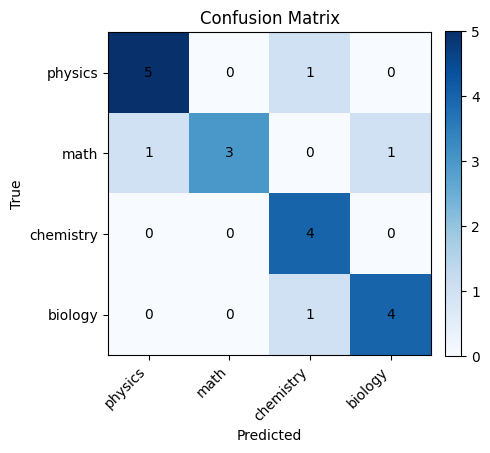

In [304]:
# --- Print a Confusion Matrix given predicted and ground_truths ---
import matplotlib.pyplot as plt
import numpy as np

# Build confusion matrix manually
n = len(categories)
cm = np.zeros((n, n), dtype=int)

# Count missing predictions
none_count = sum(p is None for p in predictions)
if none_count > 0:
    print(f"⚠️ Warning: {none_count} predictions were None and were excluded from the plot.")

# Fill counts, skipping None
for true, pred in zip(ground_truth, predictions):
    if pred is None:
        continue
    i = categories.index(true)
    j = categories.index(pred)
    cm[i, j] += 1

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")

# Add counts
for i in range(n):
    for j in range(n):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

# Labels and ticks
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticklabels(categories)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix" + ("(None values excluded)" if none_count > 0 else ""))

# Add colorbar
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 2️⃣ Using LLMs for Data Extraction - Structured Decoding

In structured decoding, the model’s token sampling process is constrained by a predefined output structure.
The OpenAI API Protocol supports this by allowing you to provide a JSON schema that defines the exact format of the desired output.
During decoding, the model is restricted to generating only those tokens that keep the response valid under the given schema.

Importantly, this schema is not part of the model’s prompt — it is enforced only during decoding.
This means the model itself receives no explicit instruction about the expected output structure, and fields such as "description" in the schema are not used for conditioning the model’s generation. As such, including information about the expected output format in the prompt is useful for increasing task comprehension and accuracy.

Below is a quick overview of the key properties of a JSON schema.
A schema is provided as a Python dictionary containing both a name and the actual schema definition under the "schema" key.

### 💡 Basic JSON Schema Properties (for all types)

* **`type`** – data type (`object`, `array`, `string`, `integer`, `number`, `boolean`)
* **`description`** – short explanation of the field’s meaning - optional
* **`enum`** – list of allowed values the property is restricted to

**For Objects** `{"type": "object"}`
* **`properties`** – defines allowed keys and their schemas
* **`required`** – list of mandatory keys

**For Arrays** `{"type": "array"}`

* **`items`** – schema for each array element
* **`minItems` / `maxItems`** – limit array length
* **`uniqueItems`** – require elements to be unique (`true`/`false`)

**For Strings** `{"type": "string"}`

* **`pattern`** – regex that the string must match
* **`minLength` / `maxLength`** – character length limits

**For Numbers / Integers** `{"type": "number"}`

* **`minimum` / `maximum`** – range constraints

### 💡Basic Example

In [383]:
# Example input text
text = """George Orwell published 1984 in 1949, a dystopian novel about surveillance and control."""

# Define JSON schema
schema = {
    "name": "metadata_extraction",
    "schema": {
        "type": "object",
        "properties": {
            "title": {"type": "string"},
            "publication_year": {"type": "number"},
        }
    }
}

# Create the request
response = client.chat.completions.create(
    model="1 - Ministral 8b - the fast model",
    messages=[{
        "role": "user",
        "content": f"Extract the relevant information from the text - return only the :\n\n{text}"
    }],
    temperature=0.0, # <--- Important!
    response_format={"type": "json_schema", "json_schema": schema}
)
message = response.choices[0].message.content
json_message = json.loads(message)
print(json.dumps(json_message, indent=2))

{
  "title": "1984",
  "publication_year": 1949
}


### 🧩 Exercise - Extract Cinema Screenings
In this exercise, you’ll practice extracting structured information from unstructured text.
Your goal is to identify all **movie screenings** in the paragraph below and output them as structured JSON objects.

Each screening should include:

* 🎞️ **Cinema name**
* 📅 **Date** (use `DD.MM.YYYY` format)
* ⏰ **Time** (24h format)
* 🗣️ **Language** (e.g., "German" or "English")

#### Steps

1. **Define your JSON schema** in the cell below.
   * Use appropriate data types (`string`) and regex patterns to validate dates and times.
   * Make sure all four fields are included and set as *required*.
2. **Write your prompt** to instruct the model to extract all screenings from the text using that schema.
3. **Run your code** and check whether the model correctly returns all screenings.
4. **Compare your output** with the *expected result* in the final cell to self-validate your solution.

#### Example

```json
{
  "cinema_name": "Thalia Kino Dresden",
  "date": "12.05.2024",
  "time": "18:00",
  "language": "English"
}
```

*Hint:* Remember that using `pattern` with regex is a great way to ensure your date and time formats are consistent!

In [342]:
screenings = """
The movie Oppenheimer returns to Dresden cinemas in May 2024.
The first screening takes place at Schauburg Dresden on Monday, May 5th, starting at 07:30pm, dubbed in German.
Later that week, Programmkino Ost will show the film on Wednesday, May 7th, at 8:15 pm, in the original version.
Finally, UFA Kristallpalast is hosting a late-night screening on 10.05.2024 at 21:00, also dubbed in English.
"""

In [ ]:
screening_extraction_schema = {
    "name": "screening_extraction",
    "schema": {
        <TODO>
    }
}

In [365]:
prompt = """
<TODO Prompt>
{screenings}
"""
response = client.chat.completions.create(
    model="1 - Ministral 8b - the fast model",
    messages=[{
        "role": "user",
        "content": prompt.format(screenings=screenings)
    }],
    temperature=0.0,
    response_format={
        "type": "json_schema",
        "json_schema": screening_extraction_schema
    }
)
message = response.choices[0].message.content
json_message = json.loads(message)
print(json.dumps(json_message, indent=2))

{
  "screenings": [
    {
      "cinema_name": "Schauburg Dresden",
      "date": "05.05.2024",
      "time": "19:30",
      "language": "German"
    },
    {
      "cinema_name": "Programmkino Ost",
      "date": "07.05.2024",
      "time": "20:15",
      "language": "English"
    },
    {
      "cinema_name": "UFA Kristallpalast",
      "date": "10.05.2024",
      "time": "21:00",
      "language": "English"
    }
  ]
}


You may use the following snippet to check whether the extracted data is correct. If it is, the function will print `✅ All values match.`.

In [366]:
with open("screening_times.json", "r") as f:
    ground_truth = json.loads(f.read())

compare_dicts(ground_truth, json_message)

✅ All values match.


True

### [Extra] 🧩 Exercise - Create Random Numbers

In this task, you are supposed to create a schema that lets the model generate **27 random numbers**, each between **100 and 200**.

💡 *Hint:* Use 
* `"type": "array"` with `"minItems"` / `"maxItems"` for the length and optionally `"uniqueItems"` for unique random numbers
* `"type": "number"` with `"minimum"` / `"maximum"` for the range.

In [405]:
random_number_schema = {
    "name": "random_number_generation",
    "schema": {
        <TODO>
    }
}

In [406]:
prompt = "Generate random numbers between 100 and 200!"
response = client.chat.completions.create(
    model="1 - Ministral 8b - the fast model",
    messages=[{
        "role": "user",
        "content": prompt
    }],
    temperature=0.0,
    response_format={
        "type": "json_schema",
        "json_schema": random_number_schema
    }
)
message = response.choices[0].message.content
random_numbers = json.loads(message)
print("Random Numbers:", random_numbers)
print(f"Model responsded with {len(random_numbers)} random numbers!")

Random Numbers: [105, 157, 183, 129, 171, 134, 192, 148, 161, 117, 189, 153, 198, 122, 176, 138, 166, 142, 181, 159, 173, 110, 195, 127, 163, 131, 179]
Model responsded with 27 random numbers!


### [Extra] 🧩 Exercise - Extract Contact Data (Regex & Optional Fields)

In this task, you’ll work with another short text — this time about **contact details**.
Your goal is to extract the relevant information in a clear, structured format.

Think about what kind of data should be captured and how to ensure the **correct format** for each field.

#### Steps

1. Design an appropriate **JSON schema** for the task.
   * Consider what fields are always present and which might be *optional*.
   * Use **patterns** where helpful to validate specific formats (e.g., emails, phone numbers).
2. Write a short prompt instructing the model to extract all contact information from the text.
3. Run your code and inspect the result.
4. Compare your output with the *expected result* in the final cell.

*Tip:* This task focuses on using **regex** and **optional fields** — try to make your schema both strict enough to validate structure and flexible enough to handle variations.

In [377]:
contact_info = """
For collaboration, contact Dr. Sarah Johnson (sarah.johnson@university.edu).
You may also reach lab assistant Mike via mike.thompson@ai-research.org or
call +1-202-555-0138. Press inquiries can be sent to press@university.edu.
"""

In [378]:
contact_extraction_schema = {
   "name":"contact_extraction",
   "schema":{
      <TODO>
   }
}

In [379]:
prompt = """
Please extract information from the following text:
{contact_info}
"""
response = client.chat.completions.create(
    model="1 - Ministral 8b - the fast model",
    messages=[{
        "role": "user",
        "content": prompt.format(contact_info=contact_info)
    }],
    temperature=0.0,
    response_format={
        "type": "json_schema",
        "json_schema": contact_extraction_schema
    }
)
message = response.choices[0].message.content
json_message = json.loads(message)
print(json.dumps(json_message, indent=2))

{
  "contacts": [
    {
      "name": "Dr. Sarah Johnson",
      "email": "sarah.johnson@university.edu"
    },
    {
      "name": "Mike",
      "email": "mike.thompson@ai-research.org",
      "phone": "+1-202-555-0138"
    },
    {
      "email": "press@university.edu",
      "phone": "N/A"
    }
  ]
}
